# Problem Statement

## Business Context

A telecommunications company in the United States provides internet, phone, and TV services to residential and business customers. They offer various contract plans, payment methods, and service options to meet customer needs. However, they are experiencing a high churn rate, with customers frequently switching to competitors. This is impacting revenue and long-term customer retention. To address this, the company is looking for data-driven insights to understand churn patterns and improve customer retention strategies.  

## Objective

The Retention Intelligence Unit has successfully conducted an in-depth analysis of customer data to uncover patterns influencing churn. Their findings highlight key factors contributing to customer attrition, providing an opportunity to implement targeted retention strategies.  

However, to effectively act on these insights, the team aims to operationalize them through a real-time decision-support system. The primary objective is to develop an interactive analytics platform that equips customer service teams, marketing departments, and business leaders with predictive churn insights. The successful deployment of this solution will enable timely interventions, enhance customer engagement efforts, and drive long-term customer retention.

## Data Dictionary

- **customerID**: Unique identifier for each customer.  
- **SeniorCitizen**: Indicates whether the customer is a senior citizen (binary: 0 = No, 1 = Yes).  
- **Partner**: Indicates if the customer has a partner (Yes/No).  
- **Dependents**: Indicates if the customer has dependents (Yes/No).  
- **tenure**: Number of months the customer has been with the service.  
- **PhoneService**: Indicates if the customer has a phone service (Yes/No).  
- **InternetService**: Type of internet service (DSL, Fiber optic, No).  
- **Contract**: Type of contract (Month-to-month, One year, Two year).  
- **PaymentMethod**: Method used for payment (Credit card, Electronic check, etc.).  
- **MonthlyCharges**: The monthly amount charged to the customer.  
- **TotalCharges**: The total amount charged to the customer over time.  
- **Churn**: Indicates whether the customer has left the service (Yes/No).  

# Installing and Importing Necessary Libraries

In [ ]:
!pip install pandas==2.2.2 numpy==2.0.2 scikit-learn==1.6.1 xgboost==2.1.4 joblib==1.4.2 streamlit==1.43.2 PyGithub==2.6.1 -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 223.6/223.6 MB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 301.8/301.8 kB 21.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.7/9.7 MB 111.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 410.5/410.5 kB 29.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 65.5/65.5 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 112.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 67.8 MB/s eta 0:00:00


In [ ]:
# for data manipulation
import pandas as pd

import sklearn

# for data preprocessing and pipeline creation
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import make_column_transformer
from sklearn.pipeline import make_pipeline

# for model training, tuning, and evaluation
import xgboost as xgb
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, classification_report, recall_score

# for model serialization
import joblib

# for creating a folder
import os

# for pushing deployment files to GitHub
from github import Github

In [ ]:
# Set scikit-learn's display mode to 'diagram' for better visualization of pipelines and estimators
sklearn.set_config(display='diagram')

- set_config is a function in sklearn that changes global settings for visualization.
- display='diagram' enables a more detailed and structured graphical representation of pipelines when calling display(pipeline).
- This is useful when working with Pipeline or ColumnTransformer objects to visualize preprocessing steps and model flow clearly.

# Data Loading and Overview

In [ ]:
# Load the dataset from a CSV file into a Pandas DataFrame
telecom_churn = pd.read_csv("customer_churn_data.csv")

In [ ]:
# Create a copy of the dataframe
dataset = telecom_churn.copy()

In [ ]:
# Display the first five rows of the dataset
dataset.head()

,customerID,SeniorCitizen,Partner,Dependents,tenure,PhoneService,InternetService,Contract,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,CUST0000,0,No,Yes,23,No,No,Month-to-month,Bank transfer,49.85,1146.55,No
1,CUST0001,0,Yes,No,43,No,DSL,Month-to-month,Mailed check,100.70,4330.10,Yes
2,CUST0002,1,No,No,51,Yes,DSL,One year,Electronic check,97.33,4963.83,Yes
3,CUST0003,1,No,No,72,Yes,DSL,Month-to-month,Credit card,101.38,7299.36,No
4,CUST0004,1,No,No,25,Yes,DSL,Month-to-month,Electronic check,52.22,1305.50,Yes


In [ ]:
# Display the number of rows and columns in the dataset
dataset.shape

(5880, 12)

In [ ]:
# Display the column names of the dataset
dataset.columns

Index(['customerID', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'InternetService', 'Contract', 'PaymentMethod',
       'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

# EDA

We'll not consider the `CustomerId` attributed as they don't add value to the analysis and consequent modeling.


In [ ]:
# Define the target variable for the classification task
target = 'Churn'  # Indicates whether the customer has left the service (Yes/No)

# List of numerical features in the dataset
numeric_features = [
    'SeniorCitizen',    # Whether the customer is a senior citizen (binary: 0 or 1)
    'tenure',           # Number of months the customer has been with the service
    'MonthlyCharges',   # Monthly amount charged to the customer
    'TotalCharges'      # Total amount charged to the customer over time
]

# List of categorical features in the dataset
categorical_features = [
    'Partner',          # Whether the customer has a partner (Yes/No)
    'Dependents',       # Whether the customer has dependents (Yes/No)
    'PhoneService',     # Whether the customer has phone service (Yes/No)
    'InternetService',  # Type of internet service (DSL, Fiber optic, No)
    'Contract',         # Type of contract (Month-to-month, One year, Two year)
    'PaymentMethod'     # Customer's preferred payment method
]

In [ ]:
# Generate summary statistics for numerical features
dataset[numeric_features].describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,5880.000000,5880.000000,5880.000000,5880.000000
mean,0.500680,36.549150,70.157779,2566.813165
std,0.500042,20.909674,28.804615,1910.017743
min,0.000000,1.000000,20.000000,20.030000
25%,0.000000,18.000000,45.717500,1020.217500
50%,1.000000,37.000000,70.155000,2136.445000
75%,1.000000,55.000000,95.457500,3767.665000
max,1.000000,72.000000,119.990000,8589.600000


- **SeniorCitizen (Binary: 0 or 1)**  
  - The mean (~0.50) suggests an almost equal distribution of senior and non-senior citizens.  
  - The median (50th percentile) is 1, indicating that more senior citizens might be slightly dominant.  

- **Tenure (Months with the Service)**  
  - Customers have a wide range of tenure (1 to 72 months).  
  - The median is 37 months, meaning half the customers have stayed for over three years.  
  - A standard deviation of ~20.91 shows a high variance in customer retention.  

- **MonthlyCharges (Recurring Charges)**  
  - The average monthly charge is around 70.16.  
  - Charges range from 20 to nearly 120, showing diverse pricing plans.  
  - The 25th percentile (45.72) and 75th percentile (95.46) indicate that most customers pay between these amounts.  

- **TotalCharges (Cumulative Payments)**  
  - The average total charge is ~2566.81, but it varies significantly (std ~1910.02).  
  - Some customers have only paid 20.03, while others have spent up to $8589.60, reflecting tenure differences.  

**Key Observations:**  
- Tenure distribution suggests a mix of new and long-term customers.  
- Higher variability in **MonthlyCharges** and **TotalCharges** indicates diverse customer segments.  
- Senior citizens might have slightly longer tenure, impacting retention strategies.

In [ ]:
dataset[categorical_features].describe()

,Partner,Dependents,PhoneService,InternetService,Contract,PaymentMethod
count,5880,5880,5880,5880,5880,5880
unique,2,2,2,3,3,4
top,Yes,No,Yes,No,Month-to-month,Credit card
freq,2995,3004,2941,2029,2020,1503


**Categorical Feature Insights:**  

- **Partner (Yes/No)**  
  - Nearly half of the customers have a partner (**Yes: 2995, No: 2885**).  
  - A slight majority do not have a partner, which may correlate with churn behavior.  

- **Dependents (Yes/No)**  
  - More customers do **not** have dependents (**No: 3004, Yes: 2876**).  
  - This could indicate that independent customers might have different service needs or higher churn rates.  

- **PhoneService (Yes/No)**  
  - Most customers have phone service (**Yes: 2941, No: 2939**), showing an almost even split.  

- **InternetService (DSL, Fiber optic, No)**  
  - The most common category is **No Internet Service (2029 customers)**.  
  - The remaining customers are split between **DSL and Fiber optic**, suggesting that a significant portion of the customer base relies only on phone service.  

- **Contract (Month-to-month, One year, Two year)**  
  - The majority of customers are on **Month-to-month contracts (2020 customers)**, which is often linked to higher churn rates.  
  - Fewer customers commit to longer-term contracts (**One-year and Two-year**).  

- **PaymentMethod (Credit card, Electronic check, Mailed check, Bank transfer)**  
  - **Credit card** is the most used payment method (**1503 customers**), followed by other methods.  
  - Payment method choice could indicate customer preferences and stability—e.g., electronic checks may be linked to higher churn.  

**Key Observations:**  
- A high number of **month-to-month contract customers** suggests potential churn risks.  
- Many customers **do not have internet service**, implying reliance on phone services.  
- **Dependents and partner status** could impact retention strategies, as independent customers might be more likely to switch providers.

In [ ]:
# Compute the proportion of each class in the target variable
dataset[target].value_counts(normalize=True)

,proportion
Churn,
No,0.507143
Yes,0.492857


- **50.7% customers did not churn (No)**  
- **40.2% customers churned (Yes)**  


# Model Training with Hyperparameter Tuning

## Data Preprocessing

In [ ]:
# Define predictor matrix (X) using selected numeric and categorical features
X = dataset[numeric_features + categorical_features]

# Define target variable
y = dataset[target].map({'No': 0, 'Yes': 1})

In [ ]:
# Split the dataset into training and test sets
Xtrain, Xtest, ytrain, ytest = train_test_split(
    X, y,              # Predictors (X) and target variable (y)
    test_size=0.2,     # 20% of the data is reserved for testing
    random_state=42    # Ensures reproducibility by setting a fixed random seed
)

In [ ]:
# Create a preprocessing pipeline for numerical and categorical features
preprocessor = make_column_transformer(
    (StandardScaler(), numeric_features),  # Scale numeric features to have mean equal to 0 and standard deviation equal to 1
    (OneHotEncoder(handle_unknown='ignore'), categorical_features)  # Encode categorical features as one-hot vectors
)

- ``make_column_transformer`` is a function from scikit-learn that helps create a preprocessing pipeline for applying different transformations to specific feature types in a dataset

### **Breakdown:**

1. **`StandardScaler()` for numeric features**  
   - Scales numerical columns (**`SeniorCitizen`, `tenure`, `MonthlyCharges`, `TotalCharges`**) to have **zero mean and unit variance**.  
   - This ensures that numerical features with different ranges are transformed to the same scale, improving model performance.  

2. **`OneHotEncoder()` for categorical features**  
   - Converts categorical columns (**`Partner`, `Dependents`, `PhoneService`, `InternetService`, `Contract`, `PaymentMethod`**) into **one-hot encoded vectors**.  
   - `handle_unknown='ignore'` ensures that any new categories encountered during inference don’t cause errors.  

This preprocessing step prepares the dataset for machine learning models by standardizing numerical values and encoding categorical data efficiently.

## Creating Model Pipeline

In [ ]:
# Initialize an XGBoost classifier
model_xgb = xgb.XGBClassifier(random_state=42)

In [ ]:
# Create a machine learning pipeline with preprocessing and model training steps
model_pipeline = make_pipeline(
    preprocessor,  # Preprocesses numerical and categorical features
    model_xgb      # XGBoost classifier for model training
)

**Explanation of `make_pipeline`**  

`make_pipeline` is a function from **scikit-learn** that creates a sequential pipeline for **data preprocessing and model training**. It ensures that all necessary transformations are applied before passing the data to the model.  

**What Happens Here?**
1. **`preprocessor`** (created using `make_column_transformer`)  
   - Standardizes numerical features (e.g., `StandardScaler`)  
   - One-hot encodes categorical features (e.g., `OneHotEncoder`)  

2. **`model_xgb` (XGboost classifier)**  
   - Trains a machine learning model **after preprocessing**  
   - Ensures that raw data is first transformed before being fed into the model  

## Model Training

In [ ]:
# Train the model pipeline on the training data
model_pipeline.fit(Xtrain, ytrain)

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(transformers=[('standardscaler',
                                                  StandardScaler(),
                                                  ['SeniorCitizen', 'tenure',
                                                   'MonthlyCharges',
                                                   'TotalCharges']),
                                                 ('onehotencoder',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['Partner', 'Dependents',
                                                   'PhoneService',
                                                   'InternetService',
                                                   'Contract',
                                                   'PaymentMethod'])])),
                ('xgbclassifier',
                 XGBClassifier(base_score...
                               feature_types=None, gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=None,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=None, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=None, n_jobs=None,
                               num_parallel_tree=None, random_state=42, ...))])

Click on each dropdown button above the pipeline architecture to view the backend process that occurs when you run the model_pipeline on the dataset

In [ ]:
# Make predictions on the training data
y_pred_train = model_pipeline.predict(Xtrain)

# Make predictions on the test data
y_pred_test = model_pipeline.predict(Xtest)

In [ ]:
# Generate a classification report to evaluate model performance on training set
print(classification_report(ytrain, y_pred_train))

              precision    recall  f1-score   support

           0       0.91      0.92      0.91      2398
           1       0.92      0.90      0.91      2306

    accuracy                           0.91      4704
   macro avg       0.91      0.91      0.91      4704
weighted avg       0.91      0.91      0.91      4704



In [ ]:
# Generate a classification report to evaluate model performance on test set
print(classification_report(ytest, y_pred_test))

              precision    recall  f1-score   support

           0       0.49      0.52      0.50       584
           1       0.50      0.47      0.48       592

    accuracy                           0.49      1176
   macro avg       0.49      0.49      0.49      1176
weighted avg       0.49      0.49      0.49      1176



The model achieves **49% accuracy**, with similar precision, recall, and F1-scores for both classes. Class 0 has **52% recall**, while class 1 has **47% recall**, indicating the model struggles to balance predictions. The overall performance suggests the need for further optimization, such as feature engineering or hyperparameter tuning.

## Hyperparameter Tuning

In [ ]:
# Define the preprocessing steps
preprocessor = make_column_transformer(
    (StandardScaler(), numeric_features),
    (OneHotEncoder(handle_unknown='ignore'), categorical_features)
)

In [ ]:
# Define base XGBoost model
xgb_model = xgb.XGBClassifier(random_state=42)

# Define hyperparameter grid
param_grid = {
    'xgbclassifier__n_estimators': [50, 100, 150, 200],    # number of tree to build
    'xgbclassifier__max_depth': [2, 3, 4],    # maximum depth of each tree
    'xgbclassifier__colsample_bytree': [0.4, 0.5, 0.6],    # percentage of attributes to be considered (randomly) for each tree
    'xgbclassifier__colsample_bylevel': [0.4, 0.5, 0.6],    # percentage of attributes to be considered (randomly) for each level of a tree
    'xgbclassifier__learning_rate': [0.01, 0.05, 0.1],    # learning rate
    'xgbclassifier__reg_lambda': [0.4, 0.5, 0.6],    # L2 regularization factor
}

The following code, which includes model pipeline creation and hyperparameter tuning using GridSearchCV, will take approximately 10-15 minutes to complete. Please allow sufficient time for execution.

In [ ]:
# Model pipeline
model_pipeline = make_pipeline(preprocessor, xgb_model)

# Hyperparameter tuning with GridSearchCV
grid_search = GridSearchCV(model_pipeline, param_grid, cv=5, n_jobs=-1)
grid_search.fit(Xtrain, ytrain)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('columntransformer',
                                        ColumnTransformer(transformers=[('standardscaler',
                                                                         StandardScaler(),
                                                                         ['SeniorCitizen',
                                                                          'tenure',
                                                                          'MonthlyCharges',
                                                                          'TotalCharges']),
                                                                        ('onehotencoder',
                                                                         OneHotEncoder(handle_unknown='ignore'),
                                                                         ['Partner',
                                                                          'Dependents',
                                                                          'PhoneService',
                                                                          'InternetService',
                                                                          'Contract',
                                                                          'PaymentMethod'])])),
                                       ('xgbclassifi...
                                                      n_jobs=None,
                                                      num_parallel_tree=None,
                                                      random_state=42, ...))]),
             n_jobs=-1,
             param_grid={'xgbclassifier__colsample_bylevel': [0.4, 0.5, 0.6],
                         'xgbclassifier__colsample_bytree': [0.4, 0.5, 0.6],
                         'xgbclassifier__learning_rate': [0.01, 0.05, 0.1],
                         'xgbclassifier__max_depth': [2, 3, 4],
                         'xgbclassifier__n_estimators': [50, 100, 150, 200],
                         'xgbclassifier__reg_lambda': [0.4, 0.5, 0.6]})

## Selecting the Best Model

In [ ]:
# Check the parameters of the best model
grid_search.best_params_

{'xgbclassifier__colsample_bylevel': 0.5,
 'xgbclassifier__colsample_bytree': 0.6,
 'xgbclassifier__learning_rate': 0.1,
 'xgbclassifier__max_depth': 4,
 'xgbclassifier__n_estimators': 200,
 'xgbclassifier__reg_lambda': 0.6}

In [ ]:
# Store the best model
best_model = grid_search.best_estimator_
best_model

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(transformers=[('standardscaler',
                                                  StandardScaler(),
                                                  ['SeniorCitizen', 'tenure',
                                                   'MonthlyCharges',
                                                   'TotalCharges']),
                                                 ('onehotencoder',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['Partner', 'Dependents',
                                                   'PhoneService',
                                                   'InternetService',
                                                   'Contract',
                                                   'PaymentMethod'])])),
                ('xgbclassifier',
                 XGBClassifier(base_score...
                               feature_types=None, gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=0.1,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=4, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=200, n_jobs=None,
                               num_parallel_tree=None, random_state=42, ...))])

The classification threshold is important because it controls precision and recall trade-offs.
- Since customer churn prediction is a retention problem, a higher recall is preferred. We want to correctly identify as many churners as possible, even if it means getting some false positives.
- We'll lower the classification threshold to 0.45 from 0.5 to increase the recall.

In [ ]:
# Set the classification threshold
classification_threshold = 0.45

In [ ]:
# Make predictions on the training data
y_pred_train_proba = best_model.predict_proba(Xtrain)[:, 1]
y_pred_train = (y_pred_train_proba >= classification_threshold).astype(int)

# Make predictions on the test data
y_pred_test_proba = best_model.predict_proba(Xtest)[:, 1]
y_pred_test = (y_pred_test_proba >= classification_threshold).astype(int)

In [ ]:
# Generate a classification report to evaluate model performance on training set
print(classification_report(ytrain, y_pred_train))

              precision    recall  f1-score   support

           0       0.82      0.55      0.66      2398
           1       0.65      0.87      0.75      2306

    accuracy                           0.71      4704
   macro avg       0.73      0.71      0.70      4704
weighted avg       0.74      0.71      0.70      4704



In [ ]:
# Generate a classification report to evaluate model performance on test set
print(classification_report(ytest, y_pred_test))

              precision    recall  f1-score   support

           0       0.49      0.31      0.38       584
           1       0.50      0.68      0.58       592

    accuracy                           0.50      1176
   macro avg       0.50      0.50      0.48      1176
weighted avg       0.50      0.50      0.48      1176



- We can see that the **overfitting has significantly reduced**.
- The **test set recall for the class corresponding to churn** has also **significantly improved** (by ~25%) to 78%.
- As expected, while recall has improved, precision has dropped.

We'll go ahead with this model as our final model.

# Model Serialization

In [ ]:
# @title
# Create a folder for storing the files needed for web app deployment
os.makedirs("deployment_files", exist_ok=True)

In [ ]:
# Define the file path to save (serialize) the trained model along with the data preprocessing steps
saved_model_path = "deployment_files/churn_prediction_model_v1_0.joblib"

# Save the trained model pipeline using joblib
joblib.dump(best_model, saved_model_path)

['deployment_files/churn_prediction_model_v1_0.joblib']

This code is used to save a trained machine learning model pipeline using `joblib`, which is a library for efficient object serialization in Python.

**Breakdown:**  
1. **`saved_model_path = "churn_prediction_model_v1_0.joblib"`**  
   - Defines the file path where the model will be saved.  
   - The model will be stored as a `.joblib` file, a format optimized for large NumPy arrays and machine learning models.  
   - The last part of the filename (`v1_0`) specifies a version number, which is a good practice to track changes and maintain multiple model iterations

2. **`joblib.dump(model_pipeline, saved_model_path)`**  
   - Saves the trained `model_pipeline` object to the specified path (`model.joblib`).  
   - `joblib.dump()` is preferred over `pickle.dump()` for saving large models because it is faster and more efficient with numerical data.  
   - The saved file can be loaded later using `joblib.load("model.joblib")` for inference or further training.  

This approach ensures that the model pipeline, including preprocessing steps and the trained model, is preserved for later use.

In [ ]:
# Load the saved model pipeline from the file
saved_model = joblib.load("deployment_files/churn_prediction_model_v1_0.joblib")

1. **`joblib.load("churn_prediction_model_v1_0.joblib")`**  
   - Loads the previously saved machine learning model (or pipeline) from the `model.joblib` file.  
   - The model retains all trained parameters, including preprocessing steps and learned patterns.

2. **`saved_model`**  
   - This variable stores the deserialized model, allowing it to be used for inference, further training, or evaluation.

This allows you to reuse the trained model **without retraining it.**

In [ ]:
saved_model

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(transformers=[('standardscaler',
                                                  StandardScaler(),
                                                  ['SeniorCitizen', 'tenure',
                                                   'MonthlyCharges',
                                                   'TotalCharges']),
                                                 ('onehotencoder',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['Partner', 'Dependents',
                                                   'PhoneService',
                                                   'InternetService',
                                                   'Contract',
                                                   'PaymentMethod'])])),
                ('xgbclassifier',
                 XGBClassifier(base_score...
                               feature_types=None, gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=0.1,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=4, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=200, n_jobs=None,
                               num_parallel_tree=None, random_state=42, ...))])

Let's try making predictions on the test set using the deserialized model.

- Please ensure that the saved model is loaded before making predictions.

In [ ]:
saved_model.predict(Xtest)

array([1, 0, 1, ..., 1, 0, 1])

In [ ]:
Xtest.to_csv("x_test.csv",index=False)

- As we can see, the model can be directly used for making predictions without any retraining.

# Creating a Web App using Streamlit

We want to create a web app using Streamlit that can do the following:
1. Create a UI for users to provide their input
2. Load a serialized ML model
3. Take the user input and loaded model to make a prediction
4. Display the prediction from the model to the user

For this, we write an **`app.py`** script using the %%writefile command that'll do all the above steps in one shot.

**What is `%%writefile deployment_files/app.py`?**  
`%%writefile` is a **magic command** in Jupyter notebooks (including Google Colab) that **writes the following cell’s contents to a file**.  

- `deployment_files/app.py`: This means the contents of the cell will be saved as a Python file (`app.py`) inside the `deployment_files/` directory.

In [ ]:
%%writefile deployment_files/app.py

import streamlit as st
import pandas as pd
import joblib

# Load the trained model
def load_model():
    return joblib.load("churn_prediction_model_v1_0.joblib")

model = load_model()

# Streamlit UI for Customer Churn Prediction
st.title("Customer Churn Prediction App")
st.write("This tool predicts customer churn risk based on their details. Enter the required information below.")

# User Inputs
SeniorCitizen = st.selectbox("Is the customer a senior citizen?", [0, 1])

Partner = st.selectbox("Does the customer have a partner?", ["Yes", "No"])
Dependents = st.selectbox("Does the customer have dependents?", ["Yes", "No"])
PhoneService = st.selectbox("Does the customer have phone service?", ["Yes", "No"])
InternetService = st.selectbox(
    "Type of Internet Service",
    ["DSL", "Fiber optic", "No"]
)
Contract = st.selectbox(
    "Type of Contract",
    ["Month-to-month", "One year", "Two year"]
)
PaymentMethod = st.selectbox(
    "Payment Method",
    ["Electronic check", "Mailed check", "Bank transfer", "Credit card"]
)

tenure = st.number_input(
    "Tenure (Months with the company)",
    min_value=0,
    value=12
)

MonthlyCharges = st.number_input(
    "Monthly Charges",
    min_value=0.0,
    value=50.0
)

TotalCharges = st.number_input(
    "Total Charges",
    min_value=0.0,
    value=600.0
)

# Create input DataFrame
input_data = pd.DataFrame([{
    "SeniorCitizen": SeniorCitizen,
    "tenure": tenure,
    "MonthlyCharges": MonthlyCharges,
    "TotalCharges": TotalCharges,
    "Partner": Partner,
    "Dependents": Dependents,
    "PhoneService": PhoneService,
    "InternetService": InternetService,
    "Contract": Contract,
    "PaymentMethod": PaymentMethod
}])

# Set classification threshold
classification_threshold = 0.5

# Predict button
if st.button("Predict"):
    prediction_proba = model.predict_proba(input_data)[0, 1]
    prediction = (prediction_proba >= classification_threshold).astype(int)
    result = "churn" if prediction == 1 else "not churn"
    st.write(f"Prediction: The customer is likely to **{result}**.")
    st.write(f"Churn Probability: {prediction_proba:.2f}")

Overwriting deployment_files/app.py


In Streamlit, the methods used to take user inputs in your code are:  

### 1. **`st.number_input()`** – Numeric Input  
   - Allows users to enter numerical values (integers or floats).  
   - You can specify **minimum**, **maximum**, and **default values**.  
   - Example:  
     ```python
     CreditScore = st.number_input("Credit Score", min_value=300, max_value=900, value=650)
     ```
   - Here, the input must be between **300 and 900**, and the default is **650**.  

### 2. **`st.selectbox()`** – Dropdown Selection  
   - Displays a **dropdown menu** for users to choose from predefined options.  
   - Returns the selected option as a string.  
   - Example:  
     ```python
     Geography = st.selectbox("Geography", ["France", "Germany", "Spain"])
     ```
   - Users can only select **one** of the listed values.  

### 3. **`st.button()`** – Button for Action  
   - Displays a button that, when clicked, triggers a specific action.  
   - Example:  
     ```python
     if st.button("Predict"):
         st.write("Prediction process starts...")
     ```
   - When the user clicks **"Predict"**, the code inside the `if` block executes.  

\
Refer to the [link](https://docs.streamlit.io/develop/api-reference/widgets) here to play with more streamlit widgets

# Creating a Dependencies File

In [ ]:
%%writefile deployment_files/requirements.txt
pandas==2.2.2
numpy==2.0.2
scikit-learn==1.6.1
xgboost==2.1.4
joblib==1.4.2
streamlit==1.43.2

Writing deployment_files/requirements.txt


A **`requirements.txt`** file is essential for ensuring that your project runs smoothly across different environments. It's like a **blueprint** for setting up your ML project!

# Setting up a GitHub Repository for Codespaces Deployment

## Points to note before executing the below cells
- Create a GitHub account and generate a Personal Access Token by following the instructions provided on the document titled **`Creating GitHub Account and Generating Personal Access Token`**.
- Once you have the token, add it to **Secrets** in Google Colab. For detailed instructions, refer to the section below.

## Secrets in Colab

**Secrets** in Google Colab provide a secure way to store sensitive information such as API keys, access tokens, and passwords. Instead of hardcoding these values in your notebook, you can save them as secrets and access them securely whenever needed.

1. In the left pane of Google Colab, click the fifth icon, which looks like a key.

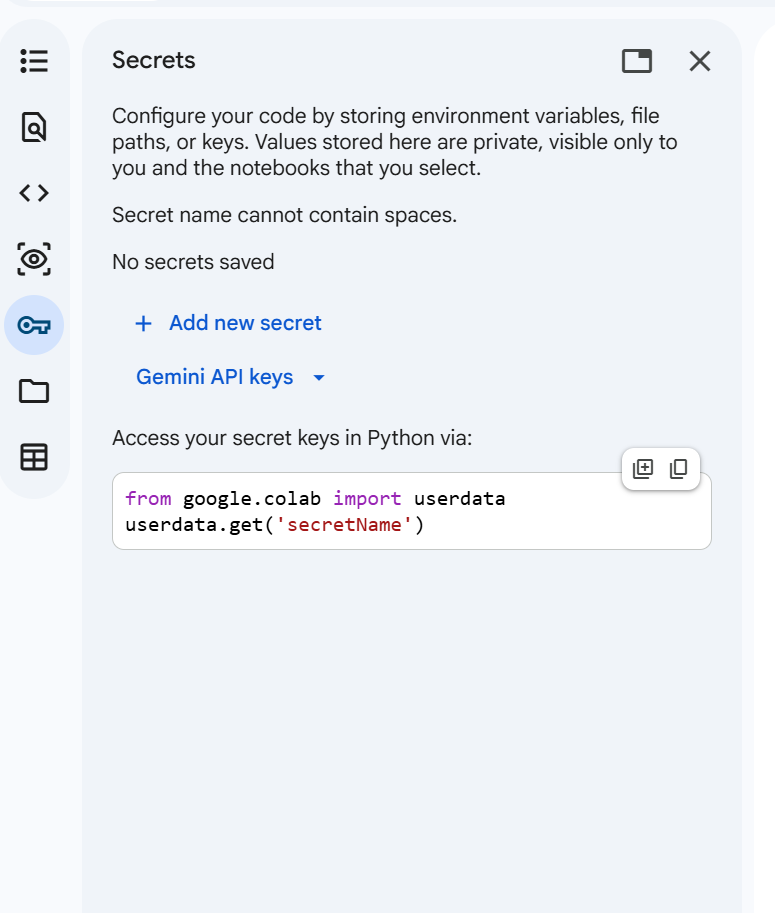

2. Then, click **+ Add new secret**. In the **Name** field, enter a name to identify the GitHub Personal Access Token, for example, **Gittoken**. In the **Value** field, paste the token. Once done, close the **Secrets** window. We will access this token programmatically later.

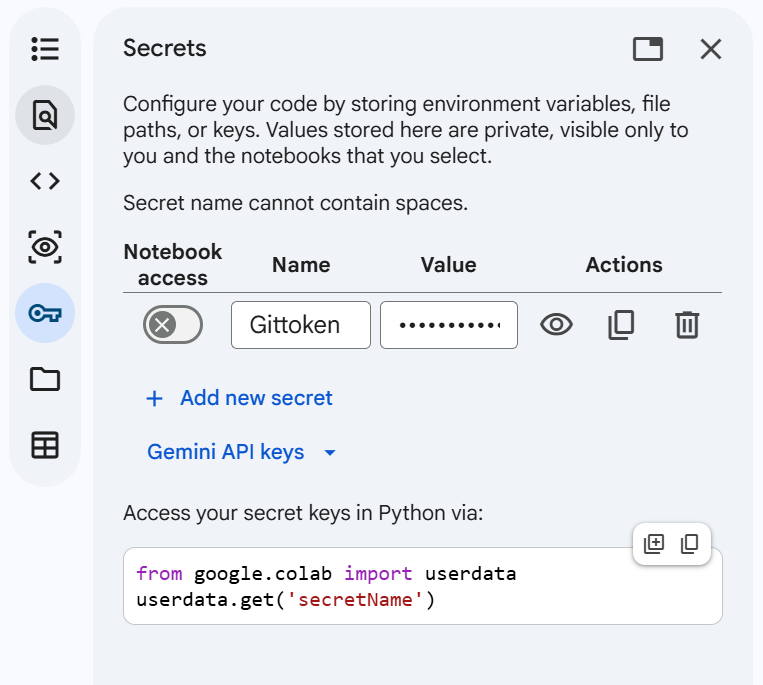

## Creating the Repository and Pushing Files to GitHub

The code below authenticates with your GitHub account using the token, creates a new public repository, and pushes all the deployment files (`app.py`, `requirements.txt`, and `churn_prediction_model_v1_0.joblib`) to it.

# Pushing Deployment Files to GitHub

We are now ready to push the files to GitHub repository

1. **Define authentication and repository details:**  
   - `GITHUB_TOKEN` stores the GitHub Personal Access Token for authentication.  
   - `REPO_NAME` specifies the name of the new GitHub repository.  

2. **Authenticate with GitHub:**  
   - `g = Github(GITHUB_TOKEN)` creates a GitHub client using the token.  
   - `user = g.get_user()` retrieves the authenticated user.  

3. **Create the repository:**  
   - `user.create_repo()` creates a new public repository on GitHub with an auto-generated README.  

4. **Push files to the repository:**  
   - `repo.create_file()` uploads each deployment file to the root of the repository.  
   - For text files (`.py`, `.txt`), PyGithub reads and uploads them directly.  
   - For the `.joblib` model file, which is binary, PyGithub handles the encoding automatically.  


In [ ]:
# Your GitHub Personal Access Token

from google.colab import userdata
GITHUB_TOKEN = userdata.get('__')  # Replace with the secret name. For example, Gittoken

# After executing this code, you may be prompted to grant access. Click **Grant Access** to continue.

In [ ]:
# Name for the new repository
REPO_NAME = "churn-prediction-app"  # Change this if you want a different name for the GitHub repository

# Authenticate with GitHub
g = Github(GITHUB_TOKEN)
user = g.get_user()
print(f"Authenticated as: {user.login}")

# Create the repository
repo = user.create_repo(
    REPO_NAME,
    description="Customer Churn Prediction — Streamlit App", # Change this if you want a different description
    private=False,
    auto_init=True  # Creates an initial README so the repo is not empty
)

print(f"Repository created successfully: {repo.html_url}")

# Dictionary mapping repo file paths to local file paths
files_to_push = {
    "app.py": "deployment_files/app.py",
    "requirements.txt": "deployment_files/requirements.txt",
    "churn_prediction_model_v1_0.joblib": "deployment_files/churn_prediction_model_v1_0.joblib",
}

for repo_path, local_path in files_to_push.items():
    # Read the file content as bytes
    with open(local_path, "rb") as f:
        content = f.read()

    # Upload the file to the repo on the main branch
    repo.create_file(
        path=repo_path,
        message=f"Add {repo_path}",
        content=content,
        branch="main"
    )
    print(f"Uploaded: {repo_path}")

print(f"\nAll files pushed successfully to: {repo.html_url}")

Authenticated as: gllearn
Repository created successfully: https://github.com/gllearn/churn-prediction-app
Uploaded: app.py
Uploaded: requirements.txt
Uploaded: churn_prediction_model_v1_0.joblib

All files pushed successfully to: https://github.com/gllearn/churn-prediction-app


Once the files have been successfully pushed to GitHub, the previous code cell will display an output similar to the following:

```text
All files pushed successfully to: https://github.com/gllearn/churn-prediction-app
```

You can click the link to open your GitHub repository and verify that all the files are present.

# Running the App in GitHub Codespaces

After the files have been pushed, refer to the content page titled **"Deploying Streamlit App on GitHub Codespace"** for the next steps to deploy the Streamlit application and see it in action.

<font size=6 color="blue">Power Ahead!</font>
___